# A/B Experiment Walkthrough

This notebook runs the whole pipeline on the simulated experiment:

1. Generate 300,000 synthetic users
2. Check for Sample Ratio Mismatch (SRM)
3. Compute metrics and run the statistical tests
4. Get the ship / continue / rollback decision
5. Look for a novelty effect
6. See how peeking inflates false positives (A/A simulation)
7. Check whether the experiment had enough power

Run it from the `notebooks/` folder, top to bottom.

In [1]:
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../src"))
os.makedirs("../data", exist_ok=True)

## 1. Generate the data
`generate_data.py` simulates a 50/50 test: 10% baseline conversion, a treatment lift that decays from +1.8pp to +1.2pp (novelty effect), gamma-distributed revenue for converters, and +15 ms latency in treatment. Importing it writes `data/experiment_data.csv`.

In [2]:
import generate_data  # noqa: F401  (runs the simulation, seed 42)

df = pd.read_csv("../data/experiment_data.csv")
print(f"{len(df):,} users")
df.head()

300,000 users


,user_id,group,converted,revenue,latency_ms,timestamp
0,0,control,0,0.0,367.709167,2025-01-01 00:00:00
1,1,treatment,0,0.0,350.575539,2025-01-01 00:00:01
2,2,treatment,0,0.0,440.234035,2025-01-01 00:00:02
3,3,treatment,0,0.0,379.162076,2025-01-01 00:00:03
4,4,control,0,0.0,441.389596,2025-01-01 00:00:04


## 2. Validate the split
A chi-square test compares group sizes with the intended 50/50 split. SRM is flagged at p < 0.001; if it were flagged, the decision would be `INVALID EXPERIMENT` no matter what the metrics show.

In [3]:
from validation import check_srm

srm = check_srm(df)
srm

{'control_users': np.int64(149666),
 'treatment_users': np.int64(150334),
 'p_value': np.float64(0.22261822986947732),
 'srm_detected': np.False_}

## 3. Metrics and statistical tests

In [4]:
from metrics import compute_metrics
from stat_tests import conversion_z_test, revenue_t_test

metrics = compute_metrics(df)
pd.DataFrame(metrics).T

,users,conversion_rate,avg_revenue,avg_latency_ms
control,149666.0,0.099882,5.937629,399.730319
treatment,150334.0,0.114804,6.902358,414.925694


In [5]:
control = df[df["group"] == "control"]
treatment = df[df["group"] == "treatment"]

conv = conversion_z_test(control["converted"], treatment["converted"])  # two-sided z-test
rev = revenue_t_test(control["revenue"], treatment["revenue"])          # Welch's t-test
latency_diff = metrics["treatment"]["avg_latency_ms"] - metrics["control"]["avg_latency_ms"]

print(f"Conversion lift: {conv['lift'] * 100:+.2f}pp (z = {conv['z_stat']:.1f}, p = {conv['p_value']:.1e})")
print(f"Revenue/user:    {rev['delta']:+.2f} (t = {rev['t_stat']:.1f}, p = {rev['p_value']:.1e})")
print(f"Latency:         {latency_diff:+.1f} ms")

Conversion lift: +1.49pp (z = 13.2, p = 8.7e-40)
Revenue/user:    +0.96 (t = 11.4, p = 2.5e-30)
Latency:         +15.2 ms


## 4. Decision
Rules, in order: SRM → invalid; conversion not significant → continue; lift < 0.5pp → no practical impact; revenue down → do not ship; latency up > 20 ms → rollback; otherwise ship.

In [6]:
from decision import make_decision

make_decision(srm["srm_detected"], conv, rev, latency_diff)

'SHIP CHANGE'

## 5. Novelty effect
The simulated lift decays from +1.8pp to +1.2pp over the run. Daily lifts are noisy, but they trend down while treatment stays above control.

group,control,treatment,lift
date,,,
2025-01-01,0.101081,0.116335,0.015254
2025-01-02,0.098186,0.116014,0.017828
2025-01-03,0.099542,0.113371,0.013830
2025-01-04,0.101667,0.112042,0.010375


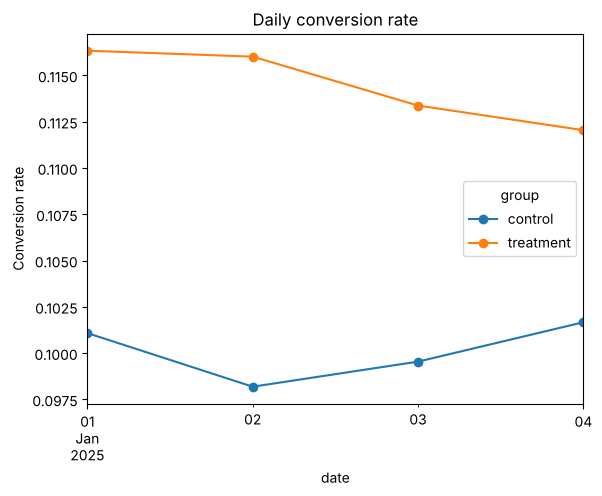

In [7]:
from time_analysis import conversion_over_time

trend = conversion_over_time(df).pivot(index="date", columns="group", values="converted")
trend["lift"] = trend["treatment"] - trend["control"]
display(trend)

ax = trend[["control", "treatment"]].plot(marker="o", title="Daily conversion rate")
ax.set_ylabel("Conversion rate");

## 6. Peeking
Checking the test after every 5,000 users and stopping at the first p < 0.05 would have ended this experiment very early:

In [8]:
from peeking_bias import simulate_peeking

simulate_peeking(df)

[{'users_seen': 10000,
  'p_value': np.float64(0.0391373408735218),
  'lift': np.float64(0.013001723918294086)}]

Here the effect is real, so stopping early happened to give the right answer. The danger shows up when there is *no* effect. The A/A simulation runs 2,000 experiments with identical groups (10,000 users each, 10 looks) and counts how often each method declares a winner:

In [9]:
from aa_simulation import METHODS, simulate_aa

aa = simulate_aa(n_experiments=2000, n_per_group=10_000, peek_every=1_000, seed=42)
pd.DataFrame({m: aa[m] for m in METHODS}).T.style.format(
    {"rate": "{:.1%}", "ci_low": "{:.1%}", "ci_high": "{:.1%}"}
)

,false_positives,rate,ci_low,ci_high
single_test,103.000000,5.1%,4.3%,6.2%
peeking,381.000000,19.1%,17.4%,20.8%
bonferroni,44.000000,2.2%,1.6%,2.9%
obrien_fleming,102.000000,5.1%,4.2%,6.2%


A single test at the planned sample size keeps false positives near 5%. Peeking at every look raises the rate to about 19%. Bonferroni (alpha / 10 per look) brings it back under 5% but is conservative. An O'Brien-Fleming boundary holds it at about 5% while still allowing an early stop for a large effect.

## 7. Power

In [10]:
from power import experiment_duration_days, power_two_proportions, sample_size_two_proportions

n_needed = sample_size_two_proportions(baseline=0.10, mde=0.012)   # long-run +1.2pp lift
n_actual = metrics["control"]["users"]
print(f"Needed per group for 80% power: {n_needed:,}")
print(f"Actual per group:               {n_actual:,}")
print(f"Achieved power:                 {power_two_proportions(0.10, 0.012, n_actual):.3f}")
print(f"Days at 20,000 visitors/day:    {experiment_duration_days(n_needed, 20_000)}")

Needed per group for 80% power: 10,330
Actual per group:               149,666
Achieved power:                 1.000
Days at 20,000 visitors/day:    2
